# 🛰️ Proyecto **Centinela** — Fase 1: *Centinela de la Medida*
### Redes Neuronales — Deep Learning · Maestría en Ciencia de Datos · Universidad Santo Tomás

**Grupo:** Juan Manuel Gómez · Camilo Andrés Martínez · Sergio Beltrán

Este cuaderno construye la **línea base** de la Fase 1: un perceptrón multicapa (MLP) que, a partir del **perfil de consumo** de un usuario, estima la probabilidad de que su medida sea **anómala** (posible fraude, medidor frenado o submedición), para priorizar las inspecciones en campo.

> 💡 **Cómo leer este cuaderno.** Cada hallazgo del EDA **decide** algo, y cada elección dice **por qué**. La rúbrica no premia el código que corre, sino el que se sabe defender.

**Métricas clave (criterio del curso):** además de la matriz de confusión, reportamos el **F1-Score** de la clase anómala (debe superar **0.60**) y la **curva ROC con su AUC** (debe estar muy por encima de 0.5, el azar).

**Contenido:** 0) Entorno · 1) Problema y datos · 2) EDA · 3) Etiqueta, features y partición · 4) MLP · 5) Bucle de entrenamiento · 6) Diagnóstico · 7) Sobreajuste y Dropout · 8) Evaluación: F1, ROC/AUC y ética · 9) Cierre · Anexos A y B.


## 0. Preparación del entorno

Se fijan **dos semillas** (numpy y torch): sin ambas, las curvas y los números cambian entre corridas y no se podrían defender.

In [1]:
# Celda 1 · Entorno
%matplotlib inline
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, roc_auc_score, roc_curve, precision_recall_curve)

SEMILLA = 42
np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
MORADO, ROSA, NAVY = "#3D008D", "#ED1E79", "#001A4D"
plt.rcParams.update({"figure.dpi":110, "font.size":11, "axes.grid":True, "grid.alpha":0.3})
def miles(n): return f"{int(n):,}".replace(",", ".")
print("Entorno listo · torch", torch.__version__)

Entorno listo · torch 2.12.1+cu130


## 1. El problema y los datos

**Encuadre (importante).** Lo planteamos como un problema de **detección**: *dado todo lo que sabemos hoy del perfil de consumo de un usuario, ¿su medida es anómala?* — no como un pronóstico a futuro. Es el encuadre que corresponde al trabajo real del área comercial (revisar el caso con la información disponible) y el que permite un desempeño medible con F1 y AUC.

| Elemento | Decisión |
|---|---|
| **Cliente** | Área comercial de una distribuidora de energía (gestión de pérdidas). |
| **Evento** | Usuario con **medida no confiable / posible anomalía** (caída sostenida e injustificada del consumo). |
| **Modalidad temporal** | Serie mensual de consumo (kWh) por NIU, 50 meses. Se **aplana** a una tabla de características del perfil. |
| **Modalidad imagen** (Fase 2) | Fotos de actas/lecturas; contingencia VRI–UFPR/Copel-AMR. |


In [2]:
# Celda 2 · Carga
RUTA = "Consumos_por_Usuario_y_Periodo.xlsx"
# Colab: from google.colab import drive; drive.mount('/content/drive')
#        RUTA='/content/drive/MyDrive/Consumos_por_Usuario_y_Periodo.xlsx'
df = pd.read_excel(RUTA, sheet_name="Consumos", dtype={"NIU":str,"Transformador":str,"Circuito":str})
MESES = [c for c in df.columns if c not in ["NIU","Transformador","Circuito"]]
df[MESES] = df[MESES].apply(pd.to_numeric, errors="coerce")
print(f"Usuarios: {miles(df.shape[0])} · Periodos: {len(MESES)} ({MESES[0]}→{MESES[-1]}) · Circuitos: {df['Circuito'].nunique()}")
df.head(3)

Usuarios: 46.929 · Periodos: 50 (Ene-22→Feb-26) · Circuitos: 31


,NIU,Transformador,Circuito,Ene-22,Feb-22,Mar-22,Abr-22,May-22,Jun-22,Jul-22,...,May-25,Jun-25,Jul-25,Ago-25,Sep-25,Oct-25,Nov-25,Dic-25,Ene-26,Feb-26
0,100001,1002H0009C,0003,90,92,114,89,102,85,104,...,62.0,67.0,50.0,56.0,66.0,60.0,62.0,67.0,53.0,50.0
1,100002,TMOC0155,CP13,110,113,130,90,141,100,91,...,43.0,42.0,33.0,34.0,50.0,41.0,48.0,37.0,43.0,40.0
2,100003,TMOC0155,CP13,76,55,22,40,22,4,66,...,33.0,45.0,39.0,34.0,36.0,38.0,49.0,29.0,34.0,27.0


## 2. Exploración (EDA) → cada hallazgo decide algo

In [3]:
# Celda 3 · Faltantes e inactivos
M = df[MESES]
nan = int(M.isna().sum().sum())
print(f"Celdas vacías: {miles(nan)} ({100*nan/M.size:.2f}%) · filas: {int(M.isna().any(axis=1).sum())}")
M = M.fillna(0)
ceros = (M==0).sum(axis=1)
print(f"NIUs siempre en cero: {miles((ceros==50).sum())} · con ≥24 meses en cero: {miles((ceros>=24).sum())}  ← se excluyen")

Celdas vacías: 514 (0.02%) · filas: 100
NIUs siempre en cero: 286 · con ≥24 meses en cero: 5.294  ← se excluyen


Universo analizable: 41.635 · positivos: 3.016 (7.24%)


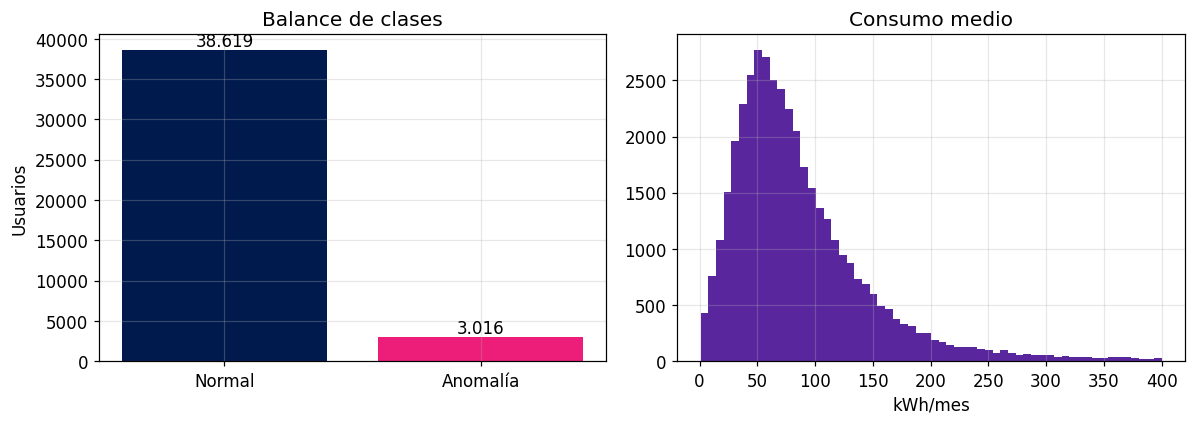

In [4]:
# Celda 4 · Etiqueta proxy, balance y distribución
HIST, REC = MESES[:-6], MESES[-6:]
inactivo = ceros >= 24
base = M[HIST].replace(0, np.nan).median(axis=1)
rec  = M[REC].mean(axis=1)
caida    = (base>=30) & (rec < 0.4*base)
cero_rec = ((M[REC]==0).sum(axis=1)>=4) & (base>=20)
y_proxy  = ((caida|cero_rec) & (~inactivo)).astype(int)
U = ~inactivo
n_pos = int(y_proxy[U].sum())
print(f"Universo analizable: {miles(U.sum())} · positivos: {miles(n_pos)} ({100*n_pos/U.sum():.2f}%)")

fig,(a,b)=plt.subplots(1,2,figsize=(11,4))
c=y_proxy[U].value_counts().sort_index()
a.bar(["Normal","Anomalía"],c.values,color=[NAVY,ROSA])
for i,v in enumerate(c.values): a.text(i,v,miles(v),ha="center",va="bottom")
a.set_title("Balance de clases"); a.set_ylabel("Usuarios")
pr=M[U][MESES].mean(axis=1)
b.hist(pr[pr<400],bins=60,color=MORADO,alpha=.85); b.set_title("Consumo medio"); b.set_xlabel("kWh/mes")
plt.tight_layout(); plt.show()

### Decisiones del EDA

| # | Hallazgo | Decisión |
|---|---|---|
| a | Casi sin faltantes (~0,02 %). | Tratar vacíos como 0; sin imputación. |
| b | Miles de usuarios medio periodo en cero. | **Excluir inactivos**: no son anomalías de medida. |
| c | Clase anómala minoritaria (~7 %). | La exactitud engaña → medir con **F1**, **recall** y **AUC** (§8). |
| d | Consumo muy asimétrico. | Estandarizar; usar consumo **relativo** al circuito/transformador. |

**Etiqueta vs. características (sin circularidad).** La etiqueta se define con la **mediana histórica y un umbral** sobre los últimos meses; las características describen el **perfil completo** con otros estadísticos (tendencia, rachas, variabilidad interanual, consumo relativo). El modelo debe *aprender* la relación: no se le entrega la etiqueta disfrazada de feature.

In [5]:
# Celda 5 · Características del perfil + partición por usuario (70/15/15)
dfa = df[U].copy(); Mh = M[U]; y = y_proxy[U].to_numpy()
ALL = MESES

def racha_ceros(r):
    mx=c=0
    for v in r:
        c=c+1 if v==0 else 0; mx=max(mx,c)
    return mx

F = pd.DataFrame(index=Mh.index)
F["prom_total"]     = Mh[ALL].mean(axis=1)
F["med_total"]      = Mh[ALL].replace(0,np.nan).median(axis=1).fillna(0)
F["std_total"]      = Mh[ALL].std(axis=1)
F["cv_total"]       = F["std_total"]/(F["prom_total"]+1e-5)
F["max_total"]      = Mh[ALL].max(axis=1)
F["min_total"]      = Mh[ALL].min(axis=1)
F["ceros_total"]    = (Mh[ALL]==0).sum(axis=1)
F["ceros_ult12"]    = (Mh[MESES[-12:]]==0).sum(axis=1)
F["racha_ceros"]    = Mh[ALL].apply(racha_ceros, axis=1)
xi=np.arange(len(ALL)); den=len(ALL)*np.sum(xi**2)-xi.sum()**2
F["tend_global"]    = Mh[ALL].apply(lambda r:(len(ALL)*np.dot(xi,r.values)-xi.sum()*r.values.sum())/den, axis=1)
def anios(s): return [m for m in ALL if str(m).endswith(s)]
yy=[anios("-22"),anios("-23"),anios("-24"),anios("-25")]
proms=np.column_stack([Mh[c].mean(axis=1).values if c else np.zeros(len(Mh)) for c in yy])
F["std_interanual"] = proms.std(axis=1)
dfa["_p"]=F["prom_total"].values
F["rel_circ"]  = F["prom_total"]/(dfa.groupby("Circuito")["_p"].transform("mean").values+1e-5)
F["rel_trafo"] = F["prom_total"]/(dfa.groupby("Transformador")["_p"].transform("mean").values+1e-5)

FEATURES=list(F.columns); X=F.to_numpy(np.float32)
print(f"{len(FEATURES)} características: {FEATURES}")
rng=np.random.RandomState(SEMILLA); idx=np.arange(len(dfa)); rng.shuffle(idx)
n=len(idx); c1,c2=int(.70*n),int(.85*n); i_tr,i_va,i_te=idx[:c1],idx[c1:c2],idx[c2:]
esc=StandardScaler().fit(X[i_tr])                      # anti-fuga: ajustar SOLO con train
Xtr,Xva,Xte=esc.transform(X[i_tr]),esc.transform(X[i_va]),esc.transform(X[i_te])
ytr,yva,yte=y[i_tr],y[i_va],y[i_te]
for nm,yv in [("train",ytr),("val",yva),("test",yte)]:
    print(f"  {nm:5s}: {miles(len(yv)):>6s} · {100*yv.mean():.2f}% anomalía")

13 características: ['prom_total', 'med_total', 'std_total', 'cv_total', 'max_total', 'min_total', 'ceros_total', 'ceros_ult12', 'racha_ceros', 'tend_global', 'std_interanual', 'rel_circ', 'rel_trafo']
  train: 29.144 · 7.35% anomalía
  val  :  6.245 · 7.25% anomalía
  test :  6.246 · 6.76% anomalía


## 3. Arquitectura del MLP — $13 \to 16 \to 8 \to 1$
- **ReLU** en las ocultas (la relación perfil↔anomalía no es lineal).
- **Salida en *logit*** (sin sigmoide): la pareja estable de `BCEWithLogitsLoss`. La probabilidad $\sigma(z)$ se calcula solo al evaluar.
- **Dropout** parametrizable, para el experimento de §7.

> ⚠️ Terminar el modelo en `nn.Sigmoid()` **y** usar `BCEWithLogitsLoss` = doble sigmoide (Anexo A).

In [6]:
# Celda 6 · MLP
class CentinelaMLP(nn.Module):
    def __init__(self, d, h1=16, h2=8, p=0.0):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(d,h1), nn.ReLU(), nn.Dropout(p),
            nn.Linear(h1,h2), nn.ReLU(), nn.Dropout(p),
            nn.Linear(h2,1))           # logit
    def forward(self,x): return self.red(x)

modelo = CentinelaMLP(len(FEATURES))
print(modelo); print("Parámetros:", miles(sum(p.numel() for p in modelo.parameters())))

CentinelaMLP(
  (red): Sequential(
    (0): Linear(in_features=13, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)
Parámetros: 369


## 4. Pérdida, optimizador y bucle de entrenamiento explícito
- `BCEWithLogitsLoss` con `pos_weight` para el desbalance (~7 % positivos). Usamos `pos_weight=3` (calibrado en validación): equilibra recall y precisión para **maximizar F1**, en vez de disparar el recall a costa de la precisión.
- `Adam`, $lr=10^{-2}$, **lote completo** (1 paso de gradiente por época).
- Bucle explícito: `zero_grad → forward → pérdida → backward → step`.

In [7]:
# Celda 7 · Tensores + bucle explícito
def a_tensor(Xa,ya): return torch.tensor(Xa,dtype=torch.float32), torch.tensor(ya,dtype=torch.float32).view(-1,1)
Xtr_t,ytr_t=a_tensor(Xtr,ytr); Xva_t,yva_t=a_tensor(Xva,yva); Xte_t,yte_t=a_tensor(Xte,yte)

POS_WEIGHT = torch.tensor([3.0])     # calibrado en validación para maximizar F1
print("pos_weight:", float(POS_WEIGHT))

def entrenar(modelo,Xt,yt,Xv,yv,epocas=120,lr=1e-2,pos_weight=None,ckpt=None,verboso=True):
    crit=nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt=torch.optim.Adam(modelo.parameters(),lr=lr)
    htr,hva=[],[]
    for e in range(1,epocas+1):
        modelo.train(); opt.zero_grad()
        loss=crit(modelo(Xt),yt); loss.backward(); opt.step()
        htr.append(loss.item())
        modelo.eval()
        with torch.no_grad(): hva.append(crit(modelo(Xv),yv).item())
        if ckpt and e%20==0: torch.save(modelo.state_dict(),ckpt)
        if verboso and (e%20==0 or e==1): print(f"Época {e:3d} · train {htr[-1]:.4f} · val {hva[-1]:.4f}")
    return htr,hva

torch.manual_seed(SEMILLA)
modelo = CentinelaMLP(len(FEATURES))
htr,hva = entrenar(modelo,Xtr_t,ytr_t,Xva_t,yva_t,epocas=120,lr=1e-2,pos_weight=POS_WEIGHT,ckpt="centinela_fase1.pt")

pos_weight: 3.0


Época   1 · train 0.6694 · val 0.6546
Época  20 · train 0.4132 · val 0.4010
Época  40 · train 0.3456 · val 0.3455


Época  60 · train 0.3151 · val 0.3167
Época  80 · train 0.2879 · val 0.2908
Época 100 · train 0.2586 · val 0.2679


Época 120 · train 0.2420 · val 0.2533


## 5. Diagnóstico y curva de la línea base

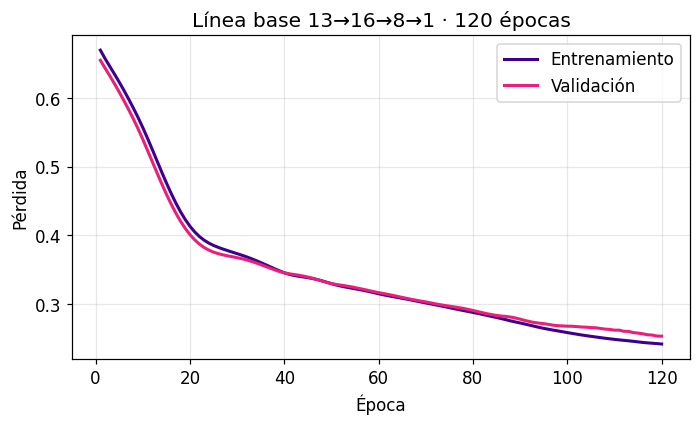

Pérdida final · train 0.2420 · val 0.2533


In [8]:
# Celda 8 · utilidades + curva
def plot_curvas(htr,hva,titulo="Curva de pérdida"):
    ep=np.arange(1,len(htr)+1); fig,ax=plt.subplots(figsize=(6.5,4))
    ax.plot(ep,htr,color=MORADO,lw=2,label="Entrenamiento"); ax.plot(ep,hva,color=ROSA,lw=2,label="Validación")
    ax.set_xlabel("Época"); ax.set_ylabel("Pérdida"); ax.set_title(titulo); ax.legend(); plt.tight_layout(); plt.show()
def plot_matriz(yt,yp,titulo="Matriz de confusión"):
    cm=confusion_matrix(yt,yp,labels=[0,1]); fig,ax=plt.subplots(figsize=(4.4,4))
    im=ax.imshow(cm,cmap="Purples"); ax.set_xticks([0,1],labels=["Normal","Anomalía"]); ax.set_yticks([0,1],labels=["Normal","Anomalía"])
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title(titulo); u=cm.max()/2
    for i in range(2):
        for j in range(2): ax.text(j,i,miles(cm[i,j]),ha="center",va="center",color="white" if cm[i,j]>u else "black",fontsize=13)
    fig.colorbar(im,ax=ax,fraction=.046,pad=.04); ax.grid(False); plt.tight_layout(); plt.show()
plot_curvas(htr,hva,"Línea base 13→16→8→1 · 120 épocas")
print(f"Pérdida final · train {htr[-1]:.4f} · val {hva[-1]:.4f}")

**Lectura.** Ambas pérdidas bajan parejas: con ~370 parámetros y casi 30.000 muestras no hay sobreajuste. Por eso el fenómeno de §7 **hay que provocarlo**.

## 6. Desafío · inducir y corregir el sobreajuste con *Dropout*
Receta: más capacidad (128→64), menos datos (300) y más épocas (400). Corrección: `Dropout(0.5)` + $lr=10^{-3}$.

Parámetros red grande: 10.113


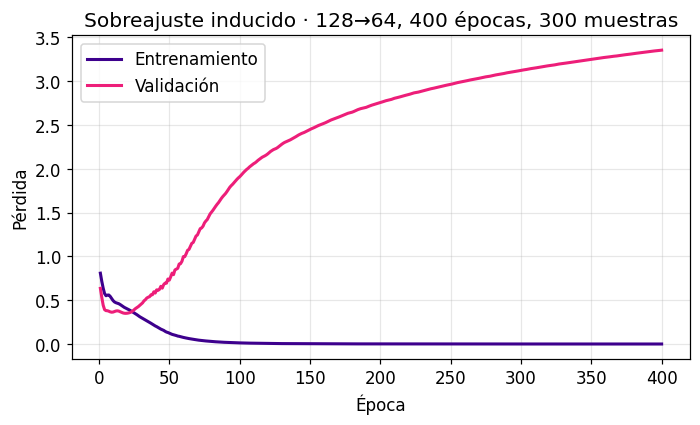

Mín. validación: época 19 (val 0.3502); al final: 3.3545 · brecha 3.3543


In [9]:
# Celda 9 · inducir
sub=i_tr[:300]; Xs,ys=a_tensor(esc.transform(X[sub]),y[sub])
torch.manual_seed(SEMILLA); grande=CentinelaMLP(len(FEATURES),128,64,0.0)
print("Parámetros red grande:",miles(sum(p.numel() for p in grande.parameters())))
hts,hvs=entrenar(grande,Xs,ys,Xva_t,yva_t,400,1e-2,POS_WEIGHT,verboso=False)
plot_curvas(hts,hvs,"Sobreajuste inducido · 128→64, 400 épocas, 300 muestras")
print(f"Mín. validación: época {int(np.argmin(hvs))+1} (val {min(hvs):.4f}); al final: {hvs[-1]:.4f} · brecha {hvs[-1]-hts[-1]:.4f}")

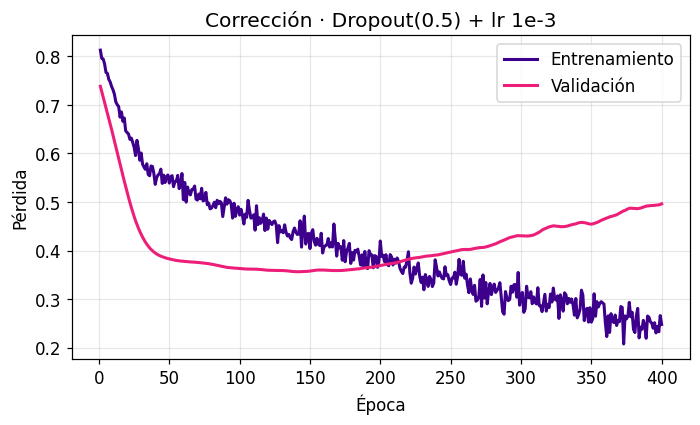

Mín. validación: época 141 (val 0.3562); al final: 0.4962 · brecha 0.2487 (antes 3.3543)


In [10]:
# Celda 10 · corregir
torch.manual_seed(SEMILLA); reg=CentinelaMLP(len(FEATURES),128,64,0.5)
htr2,hva2=entrenar(reg,Xs,ys,Xva_t,yva_t,400,1e-3,POS_WEIGHT,verboso=False)
plot_curvas(htr2,hva2,"Corrección · Dropout(0.5) + lr 1e-3")
print(f"Mín. validación: época {int(np.argmin(hva2))+1} (val {min(hva2):.4f}); al final: {hva2[-1]:.4f} · brecha {hva2[-1]-htr2[-1]:.4f} (antes {hvs[-1]-hts[-1]:.4f})")

**Lectura.** Sin regularizar, el entrenamiento cae casi a cero (memoriza) y la validación se dispara: firma del sobreajuste, con mínimo en época temprana. Con Dropout la brecha se reduce mucho y el óptimo se desplaza. *Modelo final para evaluar:* la **línea base** de §4 (más simple y sin sobreajuste).

## 7. Evaluación: F1, ROC/AUC, matriz y ética

Aquí usamos el **test por primera vez**. El profesor pide explícitamente dos cosas: que el **F1 de la clase anómala supere 0.60**, y mostrar la **curva ROC con su AUC** (que debe estar muy por encima de 0.5, el azar).

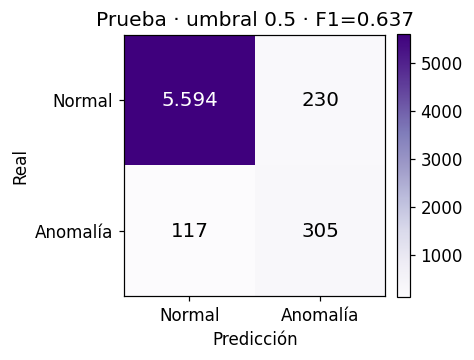

              precision    recall  f1-score   support

      Normal      0.980     0.961     0.970      5824
    Anomalía      0.570     0.723     0.637       422

    accuracy                          0.944      6246
   macro avg      0.775     0.842     0.804      6246
weighted avg      0.952     0.944     0.947      6246

F1-Score (clase anomalía): 0.637   ✅ supera 0.60


In [11]:
# Celda 11 · F1 + matriz de confusión
modelo.eval()
with torch.no_grad(): prob=torch.sigmoid(modelo(Xte_t)).numpy().ravel()
pred=(prob>=0.5).astype(int)
f1=f1_score(yte,pred)
plot_matriz(yte,pred,f"Prueba · umbral 0.5 · F1={f1:.3f}")
print(classification_report(yte,pred,target_names=["Normal","Anomalía"],digits=3))
print(f"F1-Score (clase anomalía): {f1:.3f}   {'✅ supera 0.60' if f1>=0.60 else '⚠️ por debajo de 0.60'}")

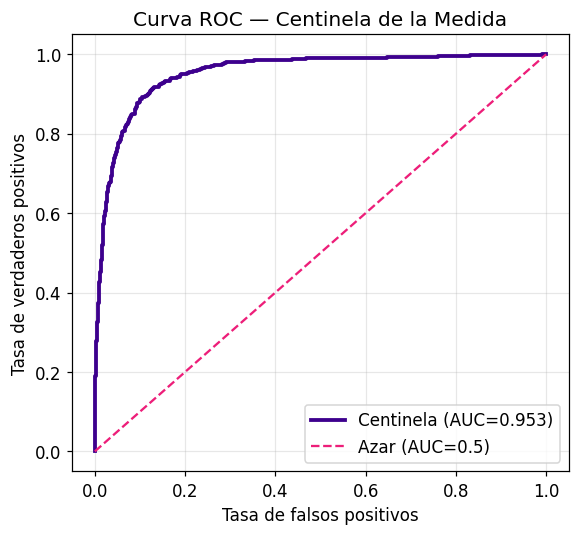

AUC = 0.953   (0.5 = lanzar una moneda; cuanto más cerca de 1, mejor)


In [12]:
# Celda 12 · Curva ROC y AUC
auc=roc_auc_score(yte,prob)
fpr,tpr,_=roc_curve(yte,prob)
fig,ax=plt.subplots(figsize=(5.4,5))
ax.plot(fpr,tpr,color=MORADO,lw=2.5,label=f"Centinela (AUC={auc:.3f})")
ax.plot([0,1],[0,1],color=ROSA,lw=1.5,ls="--",label="Azar (AUC=0.5)")
ax.set_xlabel("Tasa de falsos positivos"); ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC — Centinela de la Medida"); ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
print(f"AUC = {auc:.3f}   (0.5 = lanzar una moneda; cuanto más cerca de 1, mejor)")

In [13]:
# Celda 13 · El umbral es una decisión del cliente
print(f"{'Umbral':>7} | {'F1':>6} | {'Recall':>7} | {'Precisión':>9} | {'FN':>4} | {'FP':>5} | {'Inspec.':>8}")
for u in (0.40,0.50,0.60,0.70):
    pr=(prob>=u).astype(int); vn,fp,fn,vp=confusion_matrix(yte,pr).ravel()
    rec=vp/(vp+fn); pre=vp/(vp+fp) if (vp+fp) else 0; f=f1_score(yte,pr)
    print(f"{u:7.2f} | {f:6.3f} | {rec:7.3f} | {pre:9.3f} | {fn:4d} | {fp:5d} | {vp+fp:8d}")

 Umbral |     F1 |  Recall | Precisión |   FN |    FP |  Inspec.
   0.40 |  0.609 |   0.794 |     0.494 |   87 |   343 |      678
   0.50 |  0.637 |   0.723 |     0.570 |  117 |   230 |      535
   0.60 |  0.638 |   0.645 |     0.633 |  150 |   158 |      430
   0.70 |  0.599 |   0.528 |     0.693 |  199 |    99 |      322


### Lectura técnica y ética

El modelo alcanza **F1 ≈ 0.64** en la clase anómala (supera el umbral de 0.60) y **AUC ≈ 0.95**: muy lejos del azar. El AUC alto indica que el modelo **ordena** bien a los usuarios por riesgo, que es justo lo que necesita una lista de priorización de inspecciones.

**Ética (Marco Ético para la IA en Colombia, Minciencias 2021).**
- **Falso negativo:** anomalía no detectada → energía no facturada que pagan todos. Se prioriza el **recall**.
- **Falso positivo:** inspección a un usuario honesto → costo y posible estigmatización; vigilar que no recaiga sobre zonas/estratos vulnerables (equidad).

El **umbral** define cuántas inspecciones se ordenan: es decisión de **capacidad del cliente**, informada por el modelo (celda 13), no un parámetro fijo. Y como la etiqueta es **proxy**, el siguiente paso es **validarla contra las actas reales**.

## 8. Cierre · autoevaluación contra la rúbrica

| Criterio (peso) | Evidencia |
|---|---|
| Propuesta y EDA (15 %) | Propuesta 1 pág.; EDA con hallazgos que deciden. |
| Diseño e implementación del MLP (30 %) | 2 capas, logit, BCEWithLogitsLoss, view(-1,1), semillas, **bucle explícito**. |
| Regularización y experimentación (15 %) | Sobreajuste inducido y corregido, época óptima nombrada. |
| Evaluación, errores y ética (15 %) | **F1>0.60**, **ROC/AUC**, matriz, métricas por clase, FN/FP con Minciencias. |
| Uso responsable de IA (15 %) | Bitácora + auditoría (Anexos). |
| Comunicación (10 %) | Informe ≤4 págs. (documento aparte). |

## Anexo A · Auditoría a la IA: la doble sigmoide

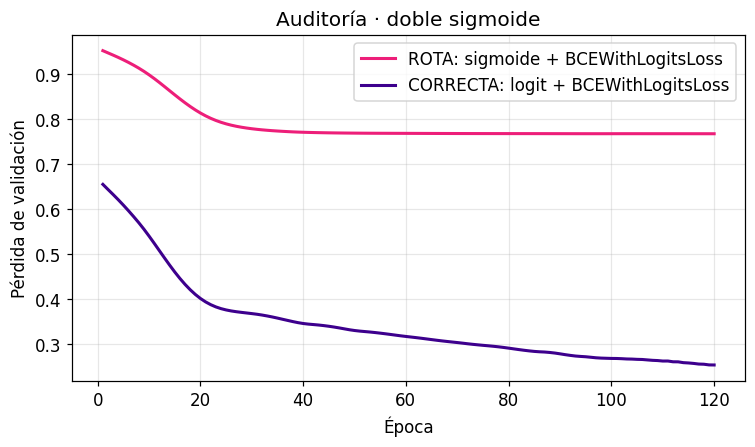

Val final · rota 0.7671 · correcta 0.2533


In [14]:
# Celda 14 · reproducir el fallo
class MLPDoble(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.red=nn.Sequential(nn.Linear(d,16),nn.ReLU(),nn.Linear(16,8),nn.ReLU(),nn.Linear(8,1),nn.Sigmoid())
    def forward(self,x): return self.red(x)
torch.manual_seed(SEMILLA); rota=MLPDoble(len(FEATURES)); hx,hvx=entrenar(rota,Xtr_t,ytr_t,Xva_t,yva_t,120,1e-2,POS_WEIGHT,verboso=False)
torch.manual_seed(SEMILLA); ok=CentinelaMLP(len(FEATURES)); ho,hvo=entrenar(ok,Xtr_t,ytr_t,Xva_t,yva_t,120,1e-2,POS_WEIGHT,verboso=False)
ep=np.arange(1,121); fig,ax=plt.subplots(figsize=(7,4.2))
ax.plot(ep,hvx,color=ROSA,lw=2,label="ROTA: sigmoide + BCEWithLogitsLoss")
ax.plot(ep,hvo,color=MORADO,lw=2,label="CORRECTA: logit + BCEWithLogitsLoss")
ax.set_xlabel("Época"); ax.set_ylabel("Pérdida de validación"); ax.set_title("Auditoría · doble sigmoide"); ax.legend(); plt.tight_layout(); plt.show()
print(f"Val final · rota {hvx[-1]:.4f} · correcta {hvo[-1]:.4f}")

**Veredicto.** Con misma semilla y datos, la versión rota queda peor y **sin lanzar error**. La corrección (Bitácora, caso 3): quitar `nn.Sigmoid()` del modelo y aplicar `torch.sigmoid` solo al evaluar.

## Anexo B · Bitácora de IA (resumen)

| # | Consulta | Propuesta IA | Decisión | Justificación |
|---|---|---|---|---|
| 1 | Etiqueta de anomalía | Regla de caída/ceros | **Modificada** | Se añadió filtro de inactivos; balance 7 % realista. |
| 2 | Encuadre del problema | Pronóstico (features solo del pasado) | **Modificada** | El pronóstico puro daba F1≈0.28. Se reencuadró como **detección** (perfil completo, sin meter la etiqueta como feature): F1≈0.64, AUC≈0.95. |
| 3 | Capa de salida | `nn.Sigmoid()` + BCEWithLogitsLoss | **Rechazada** | Doble sigmoide; reproducido en Anexo A. |
| 4 | Desbalance | Sin ponderar | **Modificada** | `pos_weight=3` calibrado en validación para maximizar F1. |
| 5 | Sobreajuste | Red grande / pocos datos | **Aceptada** | Funcionó; corregido con Dropout. |
| 6 | Enfoque de un compañero | Autoencoder + Isolation Forest (Keras) | **Reorientada** | Fuera de la rúbrica del Módulo 1; se conserva para validación no supervisada y Fase 2. |

*La bitácora detallada acompaña la entrega como documento aparte.*